# CO1 – AT3
# Exploratory Data Analysis

## Fundamentals of Data Science

**Name:** Deepak S  
**Register Number:** [Your Register Number]

---

## Question 1 – Education Analytics Dataset

A college wants to analyze student performance based on attendance, study hours, internal marks, and final result. Perform EDA to identify the factors affecting student results.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

os.makedirs("figs", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [28]:
# ============================================================
# QUESTION 1 - EDUCATION ANALYTICS DATASET
# ============================================================

education_data = {
    "Student_ID": [
        "S01", "S02", "S03", "S04", "S05",
        "S06", "S07", "S08", "S09", "S10",
        "S11", "S12", "S13", "S14", "S15",
        "S16", "S17", "S18", "S19", "S20"
    ],

    "Attendance": [
        92, 55, 78, 60, 88,
        47, 95, 72, 50, 83,
        66, 90, 58, 76, 62,
        85, 45, 80, 68, 53
    ],

    "Study_Hours": [
        5, 2, 4, 3, 5,
        1, 6, 3, 2, 4,
        3, 5, 2, 4, 3,
        5, 1, 4, 3, 2
    ],

    "Internal_Marks": [
        45, 24, 38, 28, 42,
        20, 48, 35, 22, 40,
        30, 44, 25, 36, 29,
        41, 18, 39, 32, 23
    ],

    "Result": [
        "Pass", "Fail", "Pass", "Fail", "Pass",
        "Fail", "Pass", "Pass", "Fail", "Pass",
        "Fail", "Pass", "Fail", "Pass", "Fail",
        "Pass", "Fail", "Pass", "Pass", "Fail"
    ]
}

df_education = pd.DataFrame(education_data)

print("EDUCATION DATASET")
print("=" * 50)

display(df_education)

EDUCATION DATASET


,Student_ID,Attendance,Study_Hours,Internal_Marks,Result
0,S01,92,5,45,Pass
1,S02,55,2,24,Fail
2,S03,78,4,38,Pass
3,S04,60,3,28,Fail
4,S05,88,5,42,Pass
5,S06,47,1,20,Fail
6,S07,95,6,48,Pass
7,S08,72,3,35,Pass
8,S09,50,2,22,Fail
9,S10,83,4,40,Pass


In [29]:
# ============================================================
# EDUCATION - DATASET INFORMATION AND DATA CLEANING
# ============================================================

print("DATASET INFORMATION")
print("=" * 50)

print("Number of records:", df_education.shape[0])
print("Number of features:", df_education.shape[1])

print("\nData Types:")
print(df_education.dtypes)

print("\nMissing Values:")
print(df_education.isnull().sum())

print("\nTotal Missing Values:",
      df_education.isnull().sum().sum())

print("\nDuplicate Records:",
      df_education.duplicated().sum())


# Remove duplicate records
df_education = df_education.drop_duplicates()

# Remove unwanted spaces from categorical columns
for column in df_education.select_dtypes(include="object").columns:
    df_education[column] = df_education[column].str.strip()

print("\nAFTER CLEANING")
print("=" * 50)

print("Number of records:", df_education.shape[0])
print("Number of features:", df_education.shape[1])

DATASET INFORMATION
Number of records: 20
Number of features: 5

Data Types:
Student_ID        object
Attendance         int64
Study_Hours        int64
Internal_Marks     int64
Result            object
dtype: object

Missing Values:
Student_ID        0
Attendance        0
Study_Hours       0
Internal_Marks    0
Result            0
dtype: int64

Total Missing Values: 0

Duplicate Records: 0

AFTER CLEANING
Number of records: 20
Number of features: 5


In [30]:
# ============================================================
# EDUCATION - DESCRIPTIVE STATISTICS
# ============================================================

print("DESCRIPTIVE STATISTICS")
print("=" * 50)

print(df_education.describe())

print("\nSELECTED STATISTICS")
print("=" * 50)

numeric_columns = [
    "Attendance",
    "Study_Hours",
    "Internal_Marks"
]

statistics = pd.DataFrame({
    "Mean": df_education[numeric_columns].mean(),
    "Median": df_education[numeric_columns].median(),
    "Minimum": df_education[numeric_columns].min(),
    "Maximum": df_education[numeric_columns].max(),
    "Standard Deviation": df_education[numeric_columns].std()
})

print(statistics.round(2))

DESCRIPTIVE STATISTICS
       Attendance  Study_Hours  Internal_Marks
count   20.000000    20.000000       20.000000
mean    70.150000     3.350000       32.950000
std     15.938286     1.424411        9.087151
min     45.000000     1.000000       18.000000
25%     57.250000     2.000000       24.750000
50%     70.000000     3.000000       33.500000
75%     83.500000     4.250000       40.250000
max     95.000000     6.000000       48.000000

SELECTED STATISTICS
                 Mean  Median  Minimum  Maximum  Standard Deviation
Attendance      70.15    70.0       45       95               15.94
Study_Hours      3.35     3.0        1        6                1.42
Internal_Marks  32.95    33.5       18       48                9.09


In [31]:
# ============================================================
# EDUCATION - CATEGORICAL VARIABLE ANALYSIS
# ============================================================

print("CATEGORICAL VARIABLE ANALYSIS")
print("=" * 50)

result_counts = df_education["Result"].value_counts()

print("\nResult Counts:")
print(result_counts)

print("\nResult Percentages:")
print(
    df_education["Result"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

CATEGORICAL VARIABLE ANALYSIS

Result Counts:
Result
Pass    11
Fail     9
Name: count, dtype: int64

Result Percentages:
Result
Pass    55.0
Fail    45.0
Name: proportion, dtype: float64


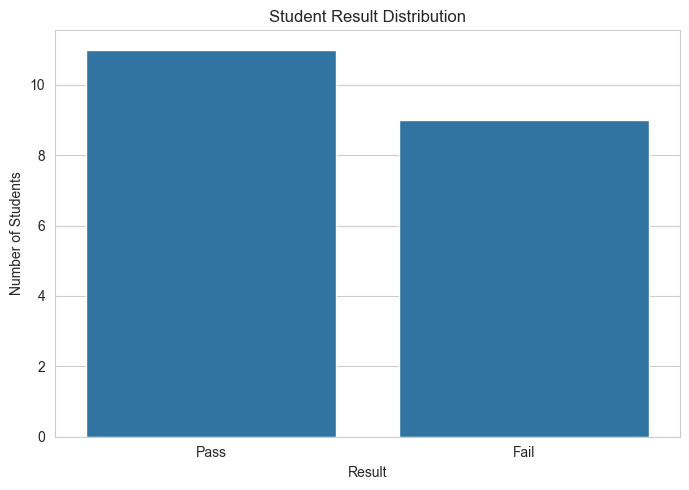

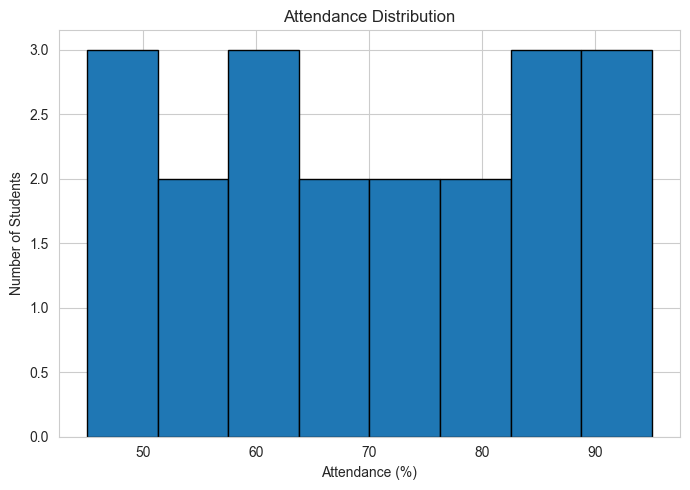

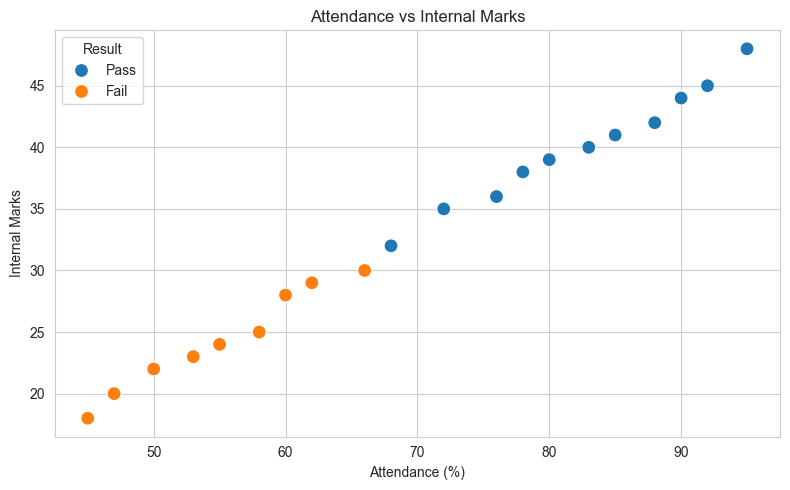

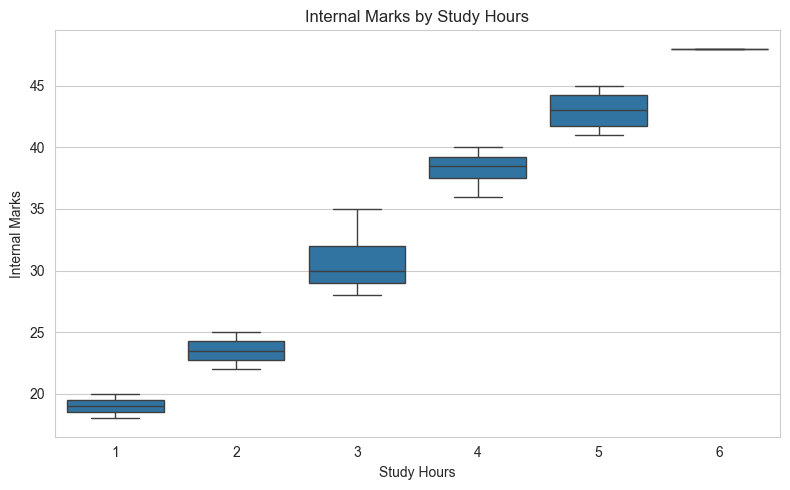

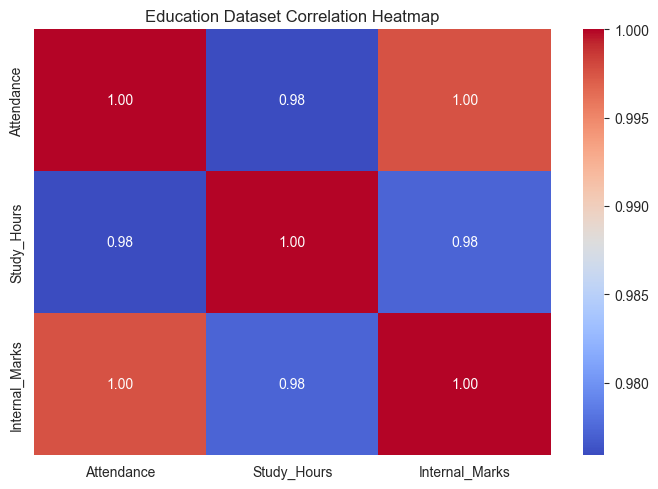

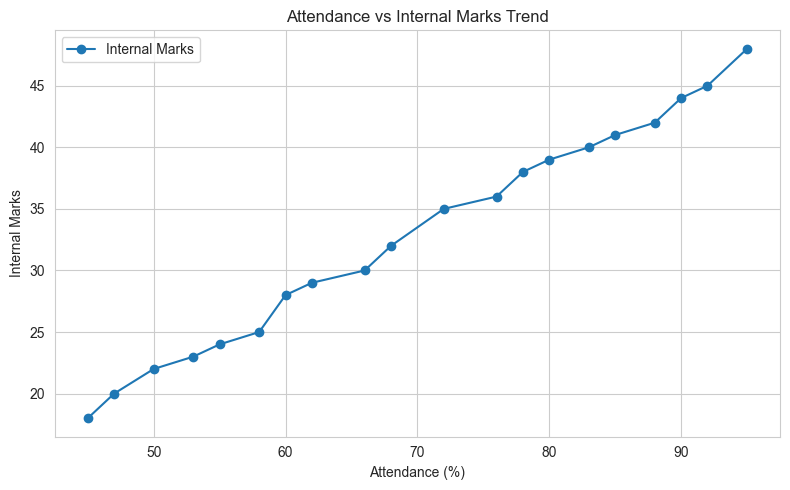

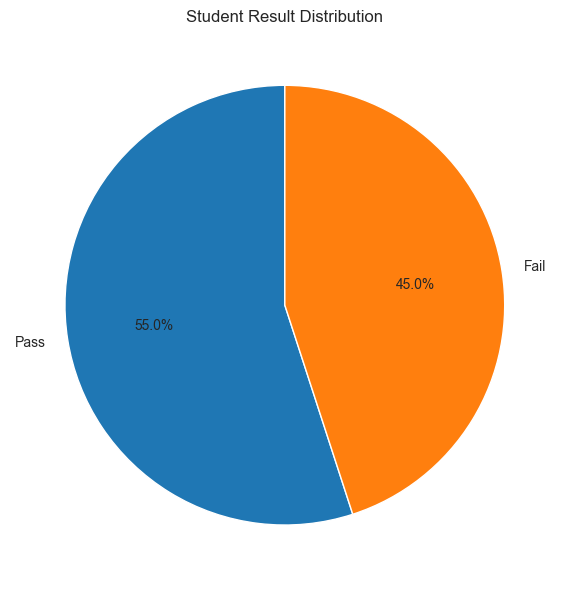

In [32]:
# ============================================================
# EDUCATION - DATA VISUALIZATION
# ============================================================

# 1. BAR CHART - Result Distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_education,
    x="Result"
)

plt.title("Student Result Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.savefig("figs/Q1_Education_Bar_Chart.png", dpi=300)
plt.show()


# 2. HISTOGRAM - Attendance Distribution

plt.figure(figsize=(7, 5))

plt.hist(
    df_education["Attendance"],
    bins=8,
    edgecolor="black"
)

plt.title("Attendance Distribution")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.savefig("figs/Q1_Education_Histogram.png", dpi=300)
plt.show()


# 3. SCATTER PLOT - Attendance vs Internal Marks

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_education,
    x="Attendance",
    y="Internal_Marks",
    hue="Result",
    s=100
)

plt.title("Attendance vs Internal Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Internal Marks")
plt.legend(title="Result")

plt.tight_layout()
plt.savefig(
    "figs/Q1_Education_Scatter_Plot.png",
    dpi=300
)
plt.show()


# 4. BOX PLOT - Study Hours vs Internal Marks

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_education,
    x="Study_Hours",
    y="Internal_Marks"
)

plt.title("Internal Marks by Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Internal Marks")

plt.tight_layout()
plt.savefig(
    "figs/Q1_Education_Box_Plot.png",
    dpi=300
)
plt.show()


# 5. HEATMAP - Numerical Correlations

plt.figure(figsize=(7, 5))

correlation = df_education[
    [
        "Attendance",
        "Study_Hours",
        "Internal_Marks"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Education Dataset Correlation Heatmap")

plt.tight_layout()
plt.savefig(
    "figs/Q1_Education_Heatmap.png",
    dpi=300
)
plt.show()


# 6. LINE CHART - Attendance vs Internal Marks

education_sorted = df_education.sort_values(
    "Attendance"
)

plt.figure(figsize=(8, 5))

plt.plot(
    education_sorted["Attendance"],
    education_sorted["Internal_Marks"],
    marker="o",
    label="Internal Marks"
)

plt.title("Attendance vs Internal Marks Trend")
plt.xlabel("Attendance (%)")
plt.ylabel("Internal Marks")
plt.legend()

plt.tight_layout()
plt.savefig(
    "figs/Q1_Education_Line_Chart.png",
    dpi=300
)
plt.show()


# 7. PIE CHART - Result Distribution

plt.figure(figsize=(6, 6))

df_education["Result"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Student Result Distribution")
plt.ylabel("")

plt.tight_layout()
plt.savefig(
    "figs/Q1_Education_Pie_Chart.png",
    dpi=300
)
plt.show()

## Education Analytics – Trends, Distributions and Relationships

Attendance and Internal Marks show a strong positive relationship. Study Hours also show a positive relationship with both Attendance and Internal Marks. Students with higher attendance and study hours generally achieve higher internal marks.

## Key Findings and Insights

1. Passing students generally have higher attendance and study hours.
2. Internal marks increase with study hours.
3. Students with lower attendance are more likely to receive a Fail result.
4. Attendance, study hours and internal marks are positively related.
5. The dataset contains 11 Pass students and 9 Fail students.

## Decision-Making Impact

The analysis can help academic advisors identify students with low attendance and study hours who may require additional mentoring and academic support.

## Conclusion

The EDA indicates that attendance, study hours and internal marks are important factors associated with student performance. Monitoring these factors can help institutions take early academic intervention measures.

# Question 2 – Healthcare Analytics Dataset

A hospital wants to analyze patient health data to identify patterns related to disease status using age, sugar level, blood pressure, and BMI.

In [33]:
# ============================================================
# QUESTION 2 - HEALTHCARE ANALYTICS DATASET
# ============================================================

healthcare_data = {
    "Patient_ID": [
        "P01", "P02", "P03", "P04", "P05",
        "P06", "P07", "P08", "P09", "P10",
        "P11", "P12", "P13", "P14", "P15",
        "P16", "P17", "P18", "P19", "P20"
    ],

    "Age": [
        45, 32, 55, 28, 60,
        40, 52, 35, 48, 30,
        62, 38, 50, 27, 58,
        42, 46, 34, 53, 29
    ],

    "Sugar_Level": [
        145, 98, 180, 90, 200,
        120, 165, 105, 155, 95,
        210, 115, 170, 88, 190,
        130, 150, 100, 175, 92
    ],

    "BP": [
        130, 118, 145, 110, 150,
        125, 140, 120, 135, 115,
        155, 122, 142, 108, 148,
        128, 132, 116, 144, 112
    ],

    "BMI": [
        28, 23, 31, 22, 34,
        26, 30, 24, 29, 23,
        35, 25, 30, 21, 33,
        27, 28, 24, 31, 22
    ],

    "Disease_Status": [
        "Yes", "No", "Yes", "No", "Yes",
        "No", "Yes", "No", "Yes", "No",
        "Yes", "No", "Yes", "No", "Yes",
        "No", "Yes", "No", "Yes", "No"
    ]
}

df_healthcare = pd.DataFrame(healthcare_data)

print("HEALTHCARE DATASET")
print("=" * 50)

display(df_healthcare)

HEALTHCARE DATASET


,Patient_ID,Age,Sugar_Level,BP,BMI,Disease_Status
0,P01,45,145,130,28,Yes
1,P02,32,98,118,23,No
2,P03,55,180,145,31,Yes
3,P04,28,90,110,22,No
4,P05,60,200,150,34,Yes
5,P06,40,120,125,26,No
6,P07,52,165,140,30,Yes
7,P08,35,105,120,24,No
8,P09,48,155,135,29,Yes
9,P10,30,95,115,23,No


In [34]:
# ============================================================
# HEALTHCARE - DATASET INFORMATION AND DATA CLEANING
# ============================================================

print("DATASET INFORMATION")
print("=" * 50)

print("Number of records:", df_healthcare.shape[0])
print("Number of features:", df_healthcare.shape[1])

print("\nData Types:")
print(df_healthcare.dtypes)

print("\nMissing Values:")
print(df_healthcare.isnull().sum())

print("\nTotal Missing Values:",
      df_healthcare.isnull().sum().sum())

print("\nDuplicate Records:",
      df_healthcare.duplicated().sum())


# Remove duplicate records
df_healthcare = df_healthcare.drop_duplicates()

# Clean categorical values
for column in df_healthcare.select_dtypes(include="object").columns:
    df_healthcare[column] = df_healthcare[column].str.strip()

print("\nAFTER CLEANING")
print("=" * 50)

print("Number of records:", df_healthcare.shape[0])
print("Number of features:", df_healthcare.shape[1])

DATASET INFORMATION
Number of records: 20
Number of features: 6

Data Types:
Patient_ID        object
Age                int64
Sugar_Level        int64
BP                 int64
BMI                int64
Disease_Status    object
dtype: object

Missing Values:
Patient_ID        0
Age               0
Sugar_Level       0
BP                0
BMI               0
Disease_Status    0
dtype: int64

Total Missing Values: 0

Duplicate Records: 0

AFTER CLEANING
Number of records: 20
Number of features: 6


In [35]:
# ============================================================
# HEALTHCARE - DESCRIPTIVE STATISTICS
# ============================================================

print("DESCRIPTIVE STATISTICS")
print("=" * 50)

print(df_healthcare.describe())

print("\nSELECTED STATISTICS")
print("=" * 50)

numeric_columns = [
    "Age",
    "Sugar_Level",
    "BP",
    "BMI"
]

statistics = pd.DataFrame({
    "Mean": df_healthcare[numeric_columns].mean(),
    "Median": df_healthcare[numeric_columns].median(),
    "Minimum": df_healthcare[numeric_columns].min(),
    "Maximum": df_healthcare[numeric_columns].max(),
    "Standard Deviation": df_healthcare[numeric_columns].std()
})

print(statistics.round(2))

DESCRIPTIVE STATISTICS
             Age  Sugar_Level          BP        BMI
count  20.000000     20.00000   20.000000  20.000000
mean   43.200000    138.65000  129.750000  27.300000
std    11.316499     40.33449   14.523574   4.256265
min    27.000000     88.00000  108.000000  21.000000
25%    33.500000     99.50000  117.500000  23.750000
50%    43.500000    137.50000  129.000000  27.500000
75%    52.250000    171.25000  142.500000  30.250000
max    62.000000    210.00000  155.000000  35.000000

SELECTED STATISTICS
               Mean  Median  Minimum  Maximum  Standard Deviation
Age           43.20    43.5       27       62               11.32
Sugar_Level  138.65   137.5       88      210               40.33
BP           129.75   129.0      108      155               14.52
BMI           27.30    27.5       21       35                4.26


In [36]:
# ============================================================
# HEALTHCARE - CATEGORICAL VARIABLE ANALYSIS
# ============================================================

print("CATEGORICAL VARIABLE ANALYSIS")
print("=" * 50)

status_counts = df_healthcare["Disease_Status"].value_counts()

print("\nDisease Status Counts:")
print(status_counts)

print("\nDisease Status Percentages:")
print(
    df_healthcare["Disease_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

CATEGORICAL VARIABLE ANALYSIS

Disease Status Counts:
Disease_Status
Yes    10
No     10
Name: count, dtype: int64

Disease Status Percentages:
Disease_Status
Yes    50.0
No     50.0
Name: proportion, dtype: float64


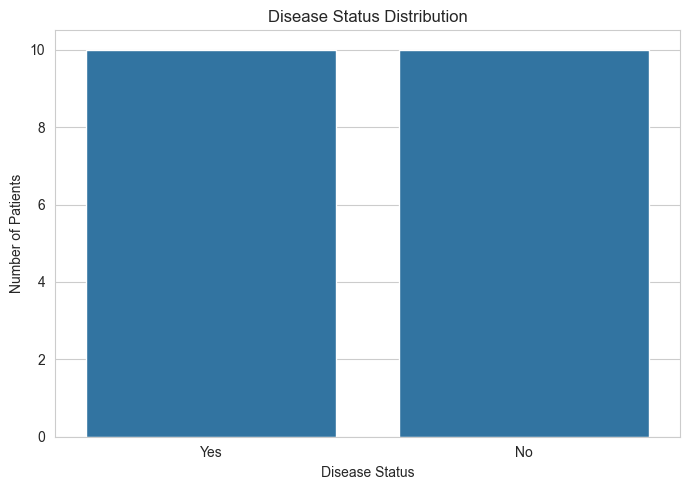

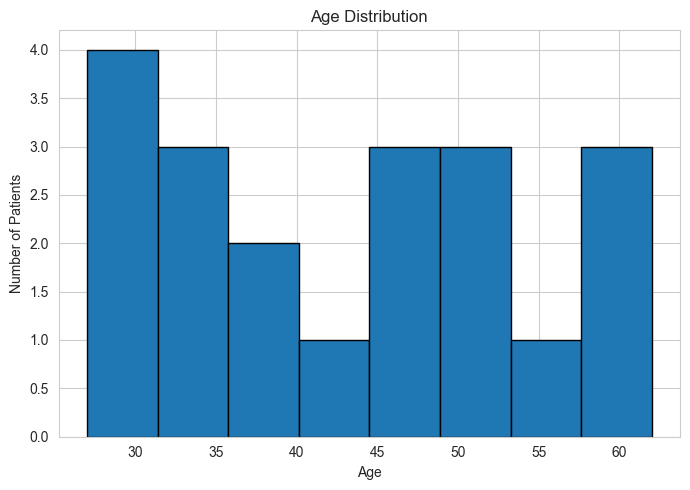

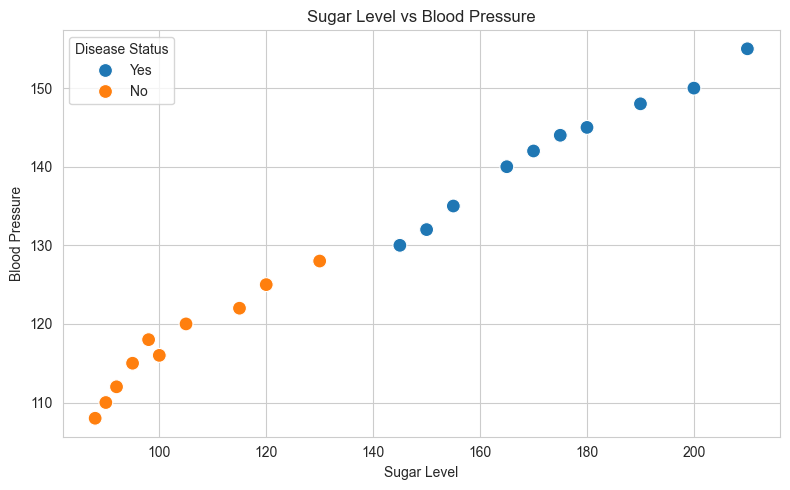

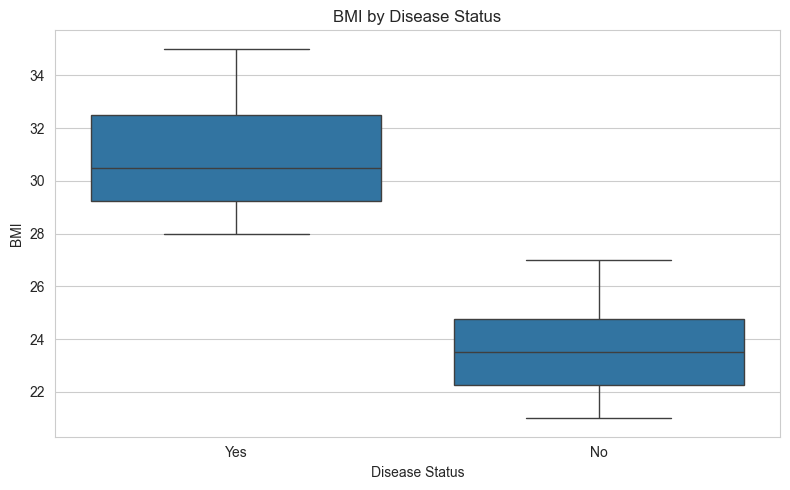

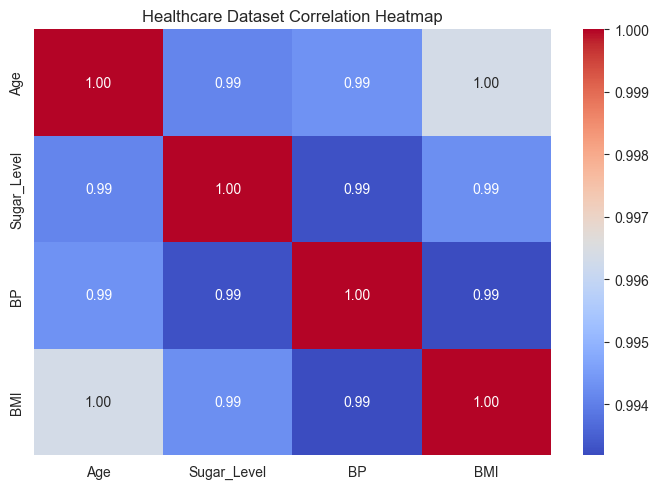

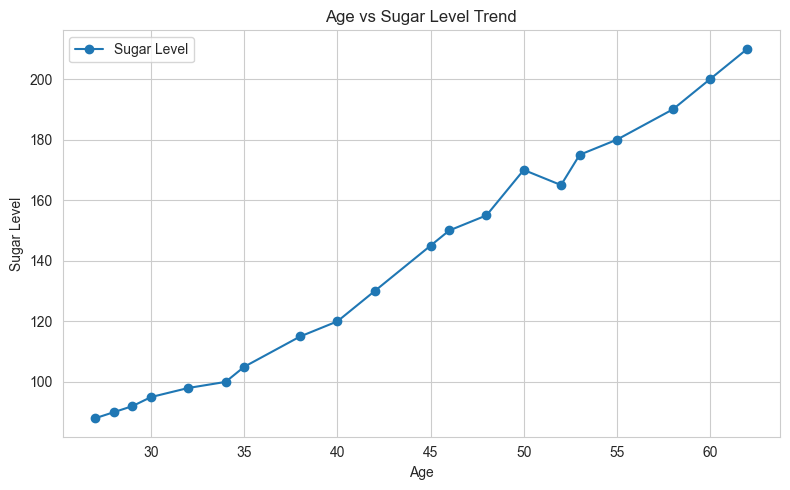

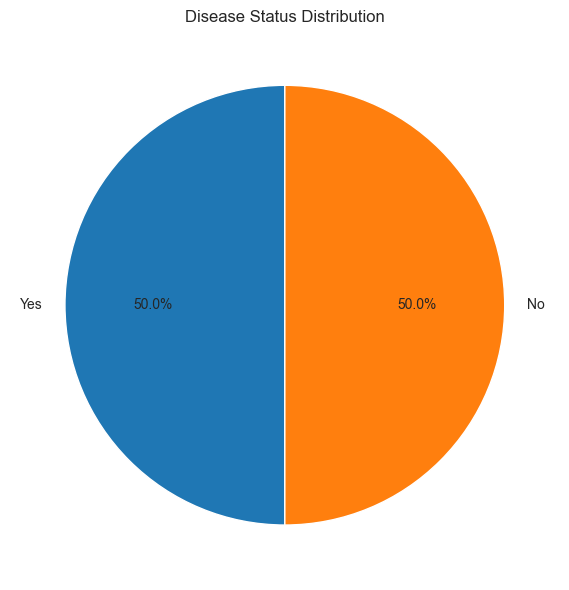

In [37]:
# ============================================================
# HEALTHCARE - DATA VISUALIZATION
# ============================================================

# 1. BAR CHART - Disease Status

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_healthcare,
    x="Disease_Status"
)

plt.title("Disease Status Distribution")
plt.xlabel("Disease Status")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.savefig("figs/Q2_Healthcare_Bar_Chart.png", dpi=300)
plt.show()


# 2. HISTOGRAM - Age Distribution

plt.figure(figsize=(7, 5))

plt.hist(
    df_healthcare["Age"],
    bins=8,
    edgecolor="black"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.savefig("figs/Q2_Healthcare_Histogram.png", dpi=300)
plt.show()


# 3. SCATTER PLOT - Sugar Level vs BP

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_healthcare,
    x="Sugar_Level",
    y="BP",
    hue="Disease_Status",
    s=100
)

plt.title("Sugar Level vs Blood Pressure")
plt.xlabel("Sugar Level")
plt.ylabel("Blood Pressure")
plt.legend(title="Disease Status")

plt.tight_layout()
plt.savefig("figs/Q2_Healthcare_Scatter_Plot.png", dpi=300)
plt.show()


# 4. BOX PLOT - BMI by Disease Status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_healthcare,
    x="Disease_Status",
    y="BMI"
)

plt.title("BMI by Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("BMI")

plt.tight_layout()
plt.savefig("figs/Q2_Healthcare_Box_Plot.png", dpi=300)
plt.show()


# 5. HEATMAP

plt.figure(figsize=(7, 5))

correlation = df_healthcare[
    [
        "Age",
        "Sugar_Level",
        "BP",
        "BMI"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Healthcare Dataset Correlation Heatmap")

plt.tight_layout()
plt.savefig("figs/Q2_Healthcare_Heatmap.png", dpi=300)
plt.show()


# 6. LINE CHART - Age vs Sugar Level

health_sorted = df_healthcare.sort_values("Age")

plt.figure(figsize=(8, 5))

plt.plot(
    health_sorted["Age"],
    health_sorted["Sugar_Level"],
    marker="o",
    label="Sugar Level"
)

plt.title("Age vs Sugar Level Trend")
plt.xlabel("Age")
plt.ylabel("Sugar Level")
plt.legend()

plt.tight_layout()
plt.savefig("figs/Q2_Healthcare_Line_Chart.png", dpi=300)
plt.show()


# 7. PIE CHART - Disease Status

plt.figure(figsize=(6, 6))

df_healthcare["Disease_Status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Disease Status Distribution")
plt.ylabel("")

plt.tight_layout()
plt.savefig("figs/Q2_Healthcare_Pie_Chart.png", dpi=300)
plt.show()

## Healthcare Analytics – Trends, Distributions and Relationships

The numerical variables show strong positive relationships. Disease-positive patients generally have higher age, sugar level, blood pressure and BMI than disease-negative patients. BMI provides a clear separation between the two disease-status groups.

## Key Findings and Insights

1. Disease-positive patients generally have higher sugar levels.
2. Disease-positive patients generally have higher blood pressure.
3. BMI provides a clear separation between disease-positive and disease-negative groups.
4. The dataset contains 10 Yes and 10 No disease-status records.
5. No missing values or duplicate records were found.

## Decision-Making Impact

BMI and sugar-level patterns can be used as preliminary screening indicators to identify patients who may require further medical examination.

## Conclusion

The EDA shows that age, sugar level, blood pressure and BMI are useful variables for understanding disease-related patterns in the dataset. The findings can support preliminary screening and preventive healthcare planning.

## Healthcare Analytics – Trends, Distributions and Relationships

The numerical variables show strong positive relationships. Disease-positive patients generally have higher age, sugar level, blood pressure and BMI than disease-negative patients. BMI provides a clear separation between the two disease-status groups.

## Key Findings and Insights

1. Disease-positive patients generally have higher sugar levels.
2. Disease-positive patients generally have higher blood pressure.
3. BMI provides a clear separation between disease-positive and disease-negative groups.
4. The dataset contains 10 Yes and 10 No disease-status records.
5. No missing values or duplicate records were found.

## Decision-Making Impact

BMI and sugar-level patterns can be used as preliminary screening indicators to identify patients who may require further medical examination.

## Conclusion

The EDA shows that age, sugar level, blood pressure and BMI are useful variables for understanding disease-related patterns in the dataset. The findings can support preliminary screening and preventive healthcare planning.

In [38]:
# ============================================================
# QUESTION 3 - RETAIL SALES DATASET
# ============================================================

retail_data = {
    "Product_ID": [
        "PR01", "PR02", "PR03", "PR04", "PR05",
        "PR06", "PR07", "PR08", "PR09", "PR10",
        "PR11", "PR12", "PR13", "PR14", "PR15",
        "PR16", "PR17", "PR18", "PR19", "PR20"
    ],

    "Category": [
        "Grocery", "Snacks", "Dairy", "Fruits", "Vegetables",
        "Grocery", "Snacks", "Dairy", "Fruits", "Vegetables",
        "Grocery", "Snacks", "Dairy", "Fruits", "Vegetables",
        "Grocery", "Snacks", "Dairy", "Fruits", "Vegetables"
    ],

    "Price": [
        50, 30, 45, 60, 40,
        80, 25, 55, 70, 35,
        90, 20, 65, 75, 45,
        100, 35, 50, 80, 30
    ],

    "Quantity_Sold": [
        20, 35, 18, 25, 30,
        15, 40, 16, 22, 28,
        12, 45, 14, 20, 26,
        10, 32, 19, 18, 35
    ],

    "Discount": [
        5, 3, 2, 5, 4,
        6, 3, 2, 5, 4,
        6, 2, 3, 5, 4,
        7, 3, 2, 6, 3
    ],

    "Revenue": [
        1000, 1050, 810, 1500, 1200,
        1200, 1000, 880, 1540, 980,
        1080, 900, 910, 1500, 1170,
        1000, 1120, 950, 1440, 1050
    ]
}

df_retail = pd.DataFrame(retail_data)

print("RETAIL SALES DATASET")
print("=" * 50)

display(df_retail)

RETAIL SALES DATASET


,Product_ID,Category,Price,Quantity_Sold,Discount,Revenue
0,PR01,Grocery,50,20,5,1000
1,PR02,Snacks,30,35,3,1050
2,PR03,Dairy,45,18,2,810
3,PR04,Fruits,60,25,5,1500
4,PR05,Vegetables,40,30,4,1200
5,PR06,Grocery,80,15,6,1200
6,PR07,Snacks,25,40,3,1000
7,PR08,Dairy,55,16,2,880
8,PR09,Fruits,70,22,5,1540
9,PR10,Vegetables,35,28,4,980


In [39]:
# ============================================================
# RETAIL - DATASET INFORMATION AND DATA CLEANING
# ============================================================

print("DATASET INFORMATION")
print("=" * 50)

print("Number of records:", df_retail.shape[0])
print("Number of features:", df_retail.shape[1])

print("\nData Types:")
print(df_retail.dtypes)

print("\nMissing Values:")
print(df_retail.isnull().sum())

print("\nTotal Missing Values:",
      df_retail.isnull().sum().sum())

print("\nDuplicate Records:",
      df_retail.duplicated().sum())


# Remove duplicate records
df_retail = df_retail.drop_duplicates()

# Clean categorical values
for column in df_retail.select_dtypes(include="object").columns:
    df_retail[column] = df_retail[column].str.strip()

print("\nAFTER CLEANING")
print("=" * 50)

print("Number of records:", df_retail.shape[0])
print("Number of features:", df_retail.shape[1])

DATASET INFORMATION
Number of records: 20
Number of features: 6

Data Types:
Product_ID       object
Category         object
Price             int64
Quantity_Sold     int64
Discount          int64
Revenue           int64
dtype: object

Missing Values:
Product_ID       0
Category         0
Price            0
Quantity_Sold    0
Discount         0
Revenue          0
dtype: int64

Total Missing Values: 0

Duplicate Records: 0

AFTER CLEANING
Number of records: 20
Number of features: 6


In [40]:
# ============================================================
# RETAIL - DESCRIPTIVE STATISTICS
# ============================================================

print("DESCRIPTIVE STATISTICS")
print("=" * 50)

print(df_retail.describe())

print("\nSELECTED STATISTICS")
print("=" * 50)

numeric_columns = [
    "Price",
    "Quantity_Sold",
    "Discount",
    "Revenue"
]

statistics = pd.DataFrame({
    "Mean": df_retail[numeric_columns].mean(),
    "Median": df_retail[numeric_columns].median(),
    "Minimum": df_retail[numeric_columns].min(),
    "Maximum": df_retail[numeric_columns].max(),
    "Standard Deviation": df_retail[numeric_columns].std()
})

print(statistics.round(2))

DESCRIPTIVE STATISTICS
            Price  Quantity_Sold   Discount      Revenue
count   20.000000      20.000000  20.000000    20.000000
mean    54.000000      24.000000   4.000000  1114.000000
std     22.803509       9.673621   1.555973   221.416493
min     20.000000      10.000000   2.000000   810.000000
25%     35.000000      17.500000   3.000000   972.500000
50%     50.000000      21.000000   4.000000  1050.000000
75%     71.250000      30.500000   5.000000  1200.000000
max    100.000000      45.000000   7.000000  1540.000000

SELECTED STATISTICS


                 Mean  Median  Minimum  Maximum  Standard Deviation
Price            54.0    50.0       20      100               22.80
Quantity_Sold    24.0    21.0       10       45                9.67
Discount          4.0     4.0        2        7                1.56
Revenue        1114.0  1050.0      810     1540              221.42


In [41]:
# ============================================================
# RETAIL - CATEGORICAL VARIABLE ANALYSIS
# ============================================================

print("CATEGORICAL VARIABLE ANALYSIS")
print("=" * 50)

category_counts = df_retail["Category"].value_counts()

print("\nCategory Counts:")
print(category_counts)

print("\nCategory Percentages:")
print(
    df_retail["Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

CATEGORICAL VARIABLE ANALYSIS

Category Counts:
Category
Grocery       4
Snacks        4
Dairy         4
Fruits        4
Vegetables    4
Name: count, dtype: int64

Category Percentages:
Category
Grocery       20.0
Snacks        20.0
Dairy         20.0
Fruits        20.0
Vegetables    20.0
Name: proportion, dtype: float64


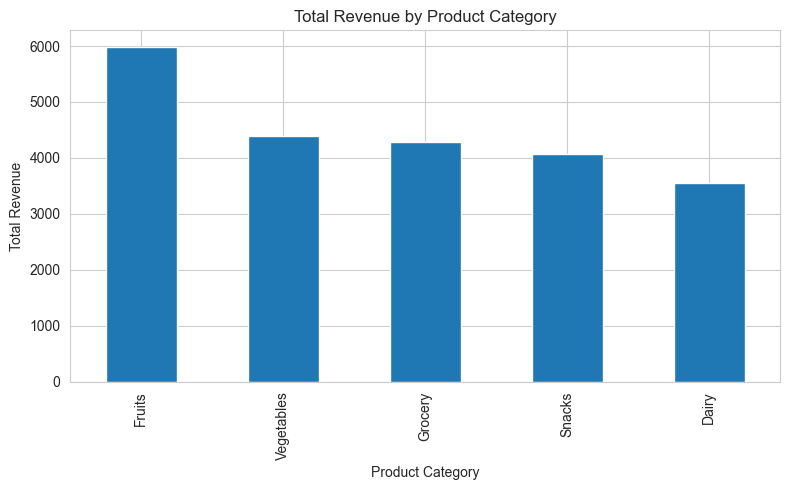

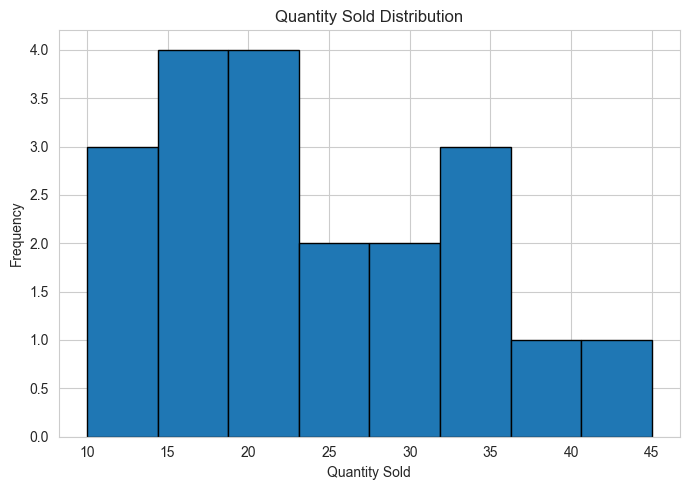

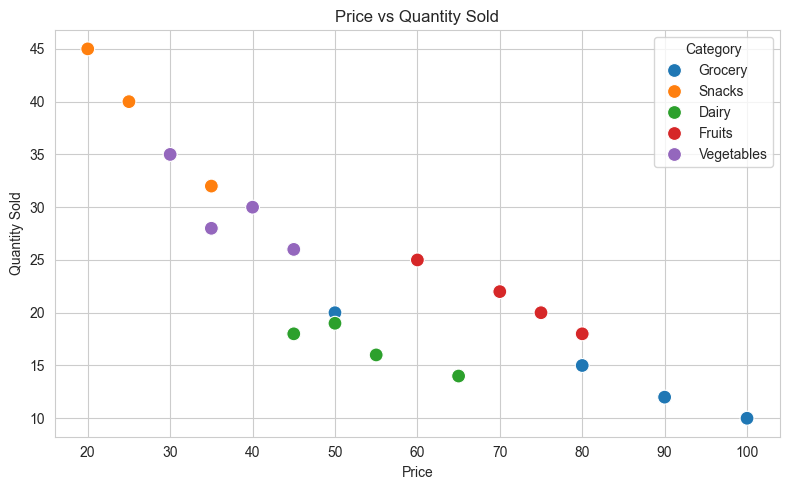

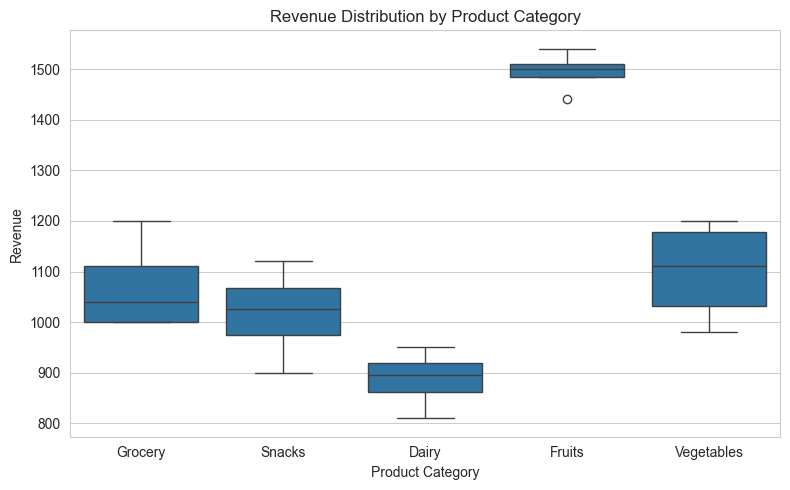

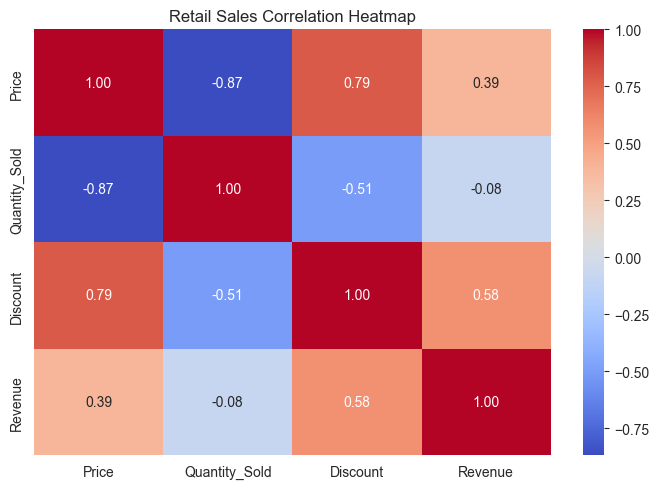

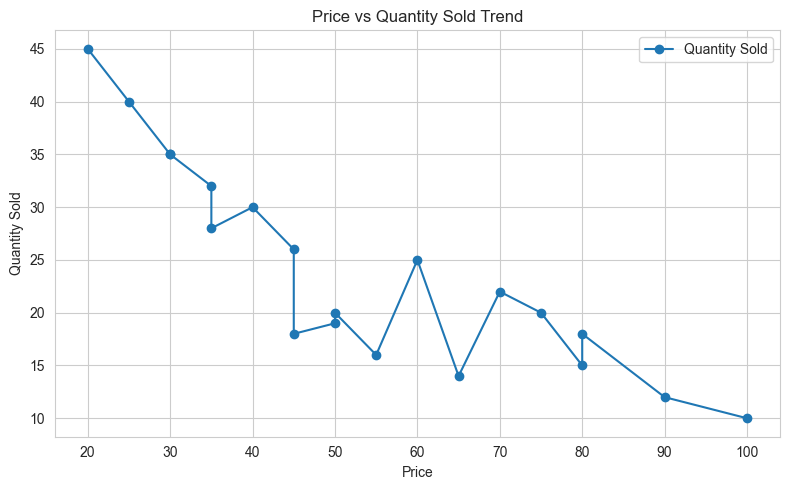

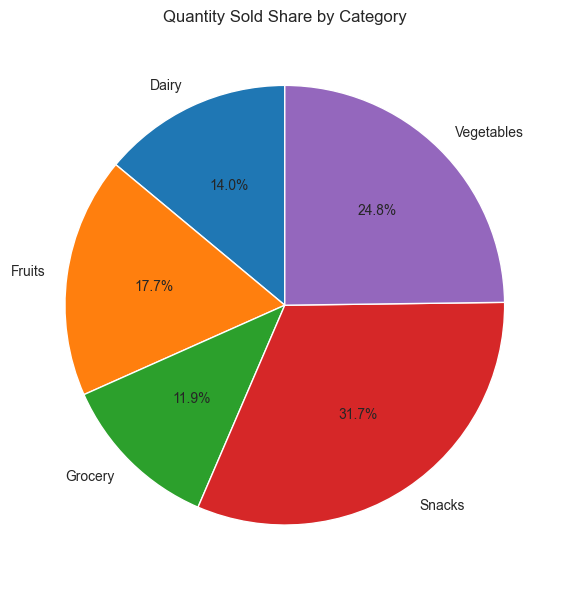

In [42]:
# ============================================================
# RETAIL - DATA VISUALIZATION
# ============================================================

# 1. BAR CHART - Revenue by Category

category_revenue = (
    df_retail.groupby("Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

category_revenue.plot(kind="bar")

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.savefig("figs/Q3_Retail_Bar_Chart.png", dpi=300)
plt.show()


# 2. HISTOGRAM - Quantity Sold

plt.figure(figsize=(7, 5))

plt.hist(
    df_retail["Quantity_Sold"],
    bins=8,
    edgecolor="black"
)

plt.title("Quantity Sold Distribution")
plt.xlabel("Quantity Sold")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("figs/Q3_Retail_Histogram.png", dpi=300)
plt.show()


# 3. SCATTER PLOT - Price vs Quantity Sold

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_retail,
    x="Price",
    y="Quantity_Sold",
    hue="Category",
    s=100
)

plt.title("Price vs Quantity Sold")
plt.xlabel("Price")
plt.ylabel("Quantity Sold")
plt.legend(title="Category")

plt.tight_layout()
plt.savefig("figs/Q3_Retail_Scatter_Plot.png", dpi=300)
plt.show()


# 4. BOX PLOT - Revenue by Category

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_retail,
    x="Category",
    y="Revenue"
)

plt.title("Revenue Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.tight_layout()
plt.savefig("figs/Q3_Retail_Box_Plot.png", dpi=300)
plt.show()


# 5. HEATMAP - Numerical Correlations

plt.figure(figsize=(7, 5))

correlation = df_retail[
    [
        "Price",
        "Quantity_Sold",
        "Discount",
        "Revenue"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Retail Sales Correlation Heatmap")

plt.tight_layout()
plt.savefig("figs/Q3_Retail_Heatmap.png", dpi=300)
plt.show()


# 6. LINE CHART - Price vs Quantity Sold

retail_sorted = df_retail.sort_values("Price")

plt.figure(figsize=(8, 5))

plt.plot(
    retail_sorted["Price"],
    retail_sorted["Quantity_Sold"],
    marker="o",
    label="Quantity Sold"
)

plt.title("Price vs Quantity Sold Trend")
plt.xlabel("Price")
plt.ylabel("Quantity Sold")
plt.legend()

plt.tight_layout()
plt.savefig("figs/Q3_Retail_Line_Chart.png", dpi=300)
plt.show()


# 7. PIE CHART - Quantity Sold by Category

plt.figure(figsize=(6, 6))

quantity_by_category = (
    df_retail.groupby("Category")["Quantity_Sold"]
    .sum()
)

quantity_by_category.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Quantity Sold Share by Category")
plt.ylabel("")

plt.tight_layout()
plt.savefig("figs/Q3_Retail_Pie_Chart.png", dpi=300)
plt.show()

## Retail Sales – Trends, Distributions and Relationships

Price and Quantity Sold show a strong inverse relationship, indicating that quantity sold generally decreases as price increases. Revenue differs across product categories, with Fruits and Vegetables showing strong revenue performance.

## Key Findings and Insights

1. Fruits generate high total revenue in the dataset.
2. Price and quantity sold show a clear inverse relationship.
3. Grocery products receive relatively higher discounts.
4. Revenue varies across product categories.
5. No missing values or duplicate records were found.

## Decision-Making Impact

The analysis can help the supermarket prioritize high-performing categories, plan stock levels, and use discounts strategically to improve sales volume.

## Conclusion

The EDA shows that product category, price, quantity sold and discount are important factors for understanding retail revenue. These insights can support pricing, promotion and inventory decisions.

# Question 4 – Banking Loan Approval Dataset

A bank wants to analyze customer and loan data to identify factors influencing loan approval decisions.

In [43]:
# ============================================================
# QUESTION 4 - BANKING LOAN APPROVAL DATASET
# ============================================================

banking_data = {
    "Customer_ID": [
        "C01", "C02", "C03", "C04", "C05",
        "C06", "C07", "C08", "C09", "C10",
        "C11", "C12", "C13", "C14", "C15",
        "C16", "C17", "C18", "C19", "C20"
    ],

    "Income": [
        45000, 25000, 60000, 22000, 50000,
        30000, 70000, 28000, 55000, 24000,
        65000, 35000, 48000, 26000, 75000,
        32000, 52000, 27000, 68000, 23000
    ],

    "Credit_Score": [
        720, 580, 750, 560, 710,
        600, 780, 590, 730, 570,
        760, 620, 700, 585, 790,
        610, 725, 575, 770, 555
    ],

    "Loan_Amount": [
        200000, 150000, 300000, 120000, 250000,
        180000, 350000, 160000, 270000, 130000,
        320000, 200000, 240000, 140000, 400000,
        190000, 260000, 150000, 330000, 125000
    ],

    "Employment_Type": [
        "Salaried", "Self-employed", "Salaried", "Unemployed",
        "Salaried", "Self-employed", "Salaried", "Self-employed",
        "Salaried", "Unemployed", "Salaried", "Self-employed",
        "Salaried", "Unemployed", "Salaried", "Self-employed",
        "Salaried", "Self-employed", "Salaried", "Unemployed"
    ],

    "Loan_Status": [
        "Approved", "Rejected", "Approved", "Rejected",
        "Approved", "Rejected", "Approved", "Rejected",
        "Approved", "Rejected", "Approved", "Rejected",
        "Approved", "Rejected", "Approved", "Rejected",
        "Approved", "Rejected", "Approved", "Rejected"
    ]
}

df_banking = pd.DataFrame(banking_data)

print("BANKING LOAN APPROVAL DATASET")
print("=" * 50)

display(df_banking)

BANKING LOAN APPROVAL DATASET


,Customer_ID,Income,Credit_Score,Loan_Amount,Employment_Type,Loan_Status
0,C01,45000,720,200000,Salaried,Approved
1,C02,25000,580,150000,Self-employed,Rejected
2,C03,60000,750,300000,Salaried,Approved
3,C04,22000,560,120000,Unemployed,Rejected
4,C05,50000,710,250000,Salaried,Approved
5,C06,30000,600,180000,Self-employed,Rejected
6,C07,70000,780,350000,Salaried,Approved
7,C08,28000,590,160000,Self-employed,Rejected
8,C09,55000,730,270000,Salaried,Approved
9,C10,24000,570,130000,Unemployed,Rejected


In [44]:
# ============================================================
# BANKING - DATASET INFORMATION AND DATA CLEANING
# ============================================================

print("DATASET INFORMATION")
print("=" * 50)

print("Number of records:", df_banking.shape[0])
print("Number of features:", df_banking.shape[1])

print("\nData Types:")
print(df_banking.dtypes)

print("\nMissing Values:")
print(df_banking.isnull().sum())

print("\nTotal Missing Values:",
      df_banking.isnull().sum().sum())

print("\nDuplicate Records:",
      df_banking.duplicated().sum())


# Remove duplicate records
df_banking = df_banking.drop_duplicates()

# Clean categorical values
for column in df_banking.select_dtypes(include="object").columns:
    df_banking[column] = df_banking[column].str.strip()

print("\nAFTER CLEANING")
print("=" * 50)

print("Number of records:", df_banking.shape[0])
print("Number of features:", df_banking.shape[1])

DATASET INFORMATION
Number of records: 20
Number of features: 6

Data Types:
Customer_ID        object
Income              int64
Credit_Score        int64
Loan_Amount         int64
Employment_Type    object
Loan_Status        object
dtype: object

Missing Values:
Customer_ID        0
Income             0
Credit_Score       0
Loan_Amount        0
Employment_Type    0
Loan_Status        0
dtype: int64

Total Missing Values: 0

Duplicate Records: 0

AFTER CLEANING
Number of records: 20
Number of features: 6


In [45]:
# ============================================================
# BANKING - DESCRIPTIVE STATISTICS
# ============================================================

print("DESCRIPTIVE STATISTICS")
print("=" * 50)

print(df_banking.describe())

print("\nSELECTED STATISTICS")
print("=" * 50)

numeric_columns = [
    "Income",
    "Credit_Score",
    "Loan_Amount"
]

statistics = pd.DataFrame({
    "Mean": df_banking[numeric_columns].mean(),
    "Median": df_banking[numeric_columns].median(),
    "Minimum": df_banking[numeric_columns].min(),
    "Maximum": df_banking[numeric_columns].max(),
    "Standard Deviation": df_banking[numeric_columns].std()
})

print(statistics.round(2))

DESCRIPTIVE STATISTICS
             Income  Credit_Score    Loan_Amount
count     20.000000     20.000000      20.000000
mean   43000.000000    664.000000  223250.000000
std    17923.815383     85.526235   83733.207272
min    22000.000000    555.000000  120000.000000
25%    26750.000000    583.750000  150000.000000
50%    40000.000000    660.000000  200000.000000
75%    56250.000000    735.000000  277500.000000
max    75000.000000    790.000000  400000.000000

SELECTED STATISTICS
                  Mean    Median  Minimum  Maximum  Standard Deviation
Income         43000.0   40000.0    22000    75000            17923.82
Credit_Score     664.0     660.0      555      790               85.53
Loan_Amount   223250.0  200000.0   120000   400000            83733.21


In [46]:
# ============================================================
# BANKING - CATEGORICAL VARIABLE ANALYSIS
# ============================================================

print("CATEGORICAL VARIABLE ANALYSIS")
print("=" * 50)

print("\nEmployment Type Counts:")
print(df_banking["Employment_Type"].value_counts())

print("\nEmployment Type Percentages:")
print(
    df_banking["Employment_Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nLoan Status Counts:")
print(df_banking["Loan_Status"].value_counts())

print("\nLoan Status Percentages:")
print(
    df_banking["Loan_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

CATEGORICAL VARIABLE ANALYSIS

Employment Type Counts:
Employment_Type
Salaried         10
Self-employed     6
Unemployed        4
Name: count, dtype: int64

Employment Type Percentages:
Employment_Type
Salaried         50.0
Self-employed    30.0
Unemployed       20.0
Name: proportion, dtype: float64

Loan Status Counts:
Loan_Status
Approved    10
Rejected    10
Name: count, dtype: int64

Loan Status Percentages:
Loan_Status
Approved    50.0
Rejected    50.0
Name: proportion, dtype: float64


<Figure size 800x500 with 0 Axes>

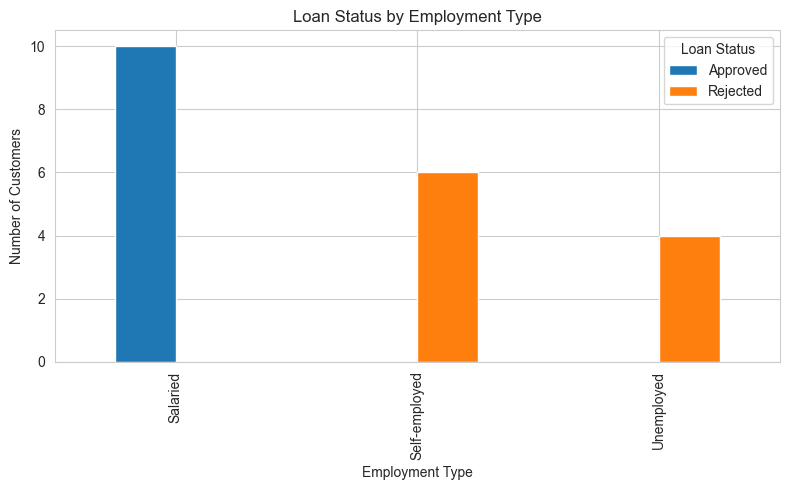

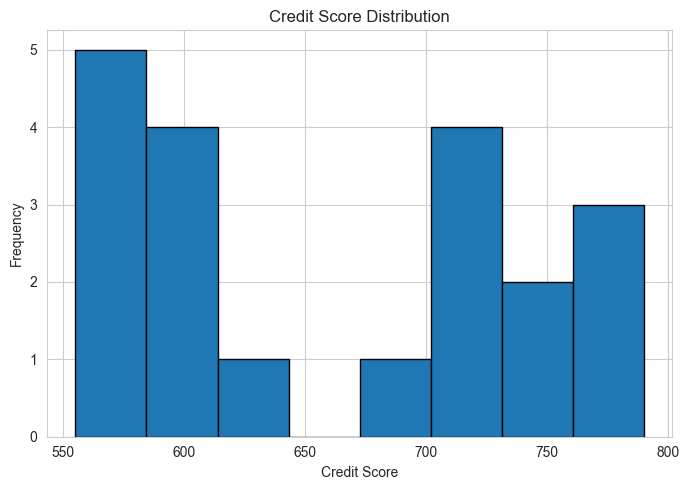

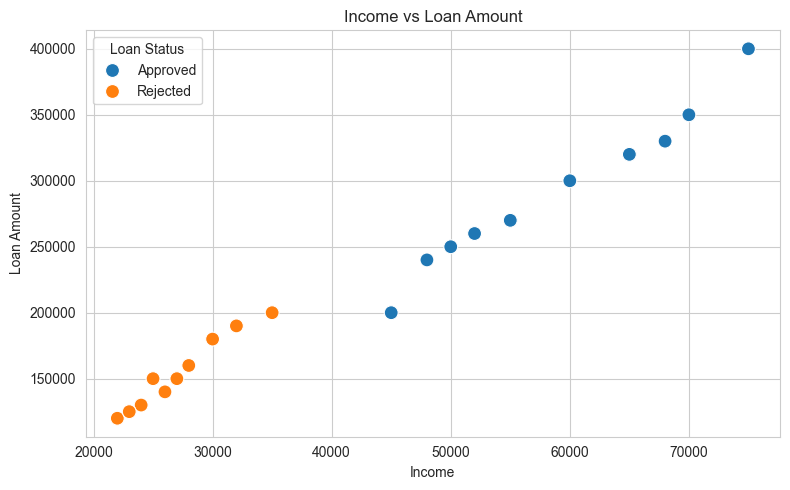

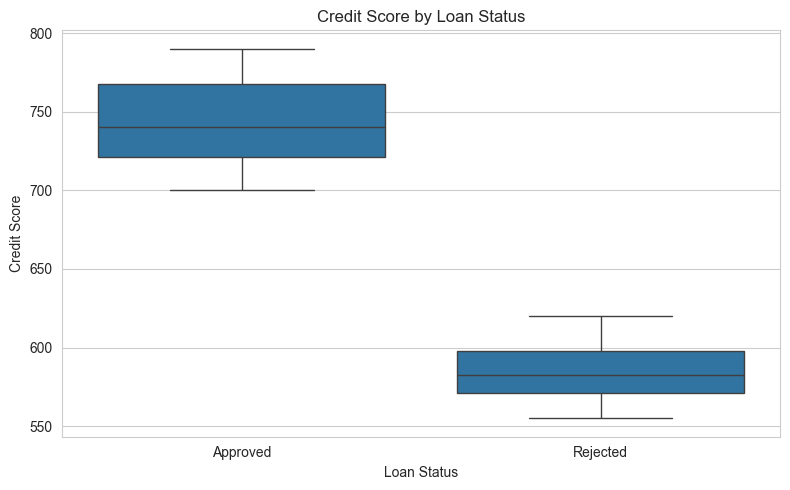

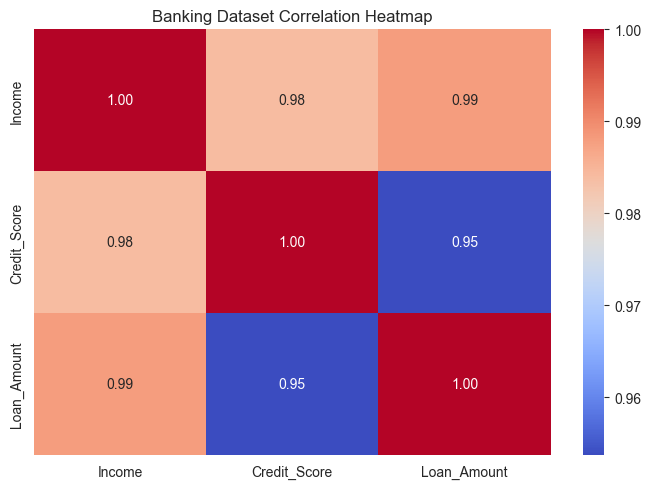

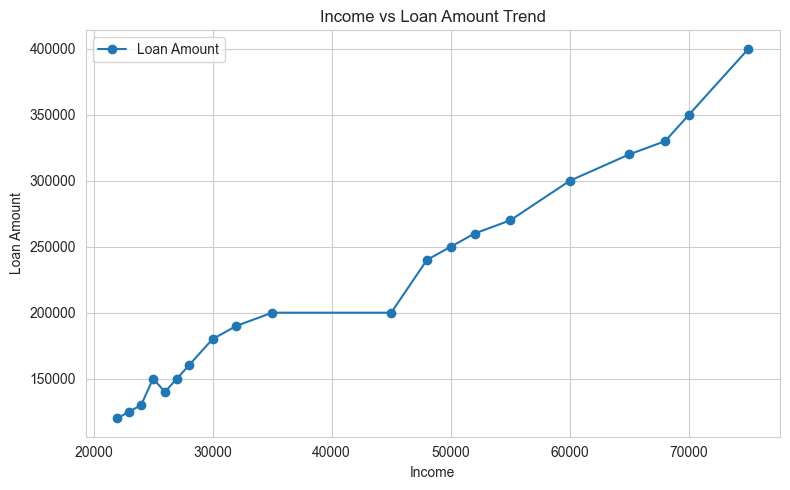

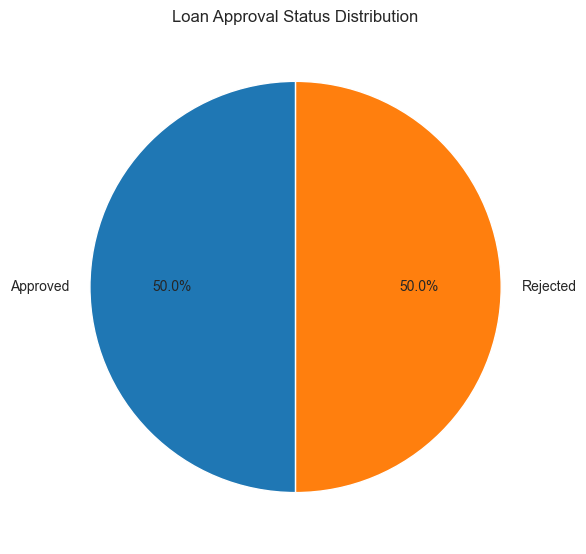

In [47]:
# ============================================================
# BANKING - DATA VISUALIZATION
# ============================================================

# 1. BAR CHART - Loan Status by Employment Type

plt.figure(figsize=(8, 5))

pd.crosstab(
    df_banking["Employment_Type"],
    df_banking["Loan_Status"]
).plot(
    kind="bar"
)

plt.title("Loan Status by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Number of Customers")
plt.legend(title="Loan Status")

plt.tight_layout()
plt.savefig("figs/Q4_Banking_Bar_Chart.png", dpi=300)
plt.show()


# 2. HISTOGRAM - Credit Score

plt.figure(figsize=(7, 5))

plt.hist(
    df_banking["Credit_Score"],
    bins=8,
    edgecolor="black"
)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("figs/Q4_Banking_Histogram.png", dpi=300)
plt.show()


# 3. SCATTER PLOT - Income vs Loan Amount

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_banking,
    x="Income",
    y="Loan_Amount",
    hue="Loan_Status",
    s=100
)

plt.title("Income vs Loan Amount")
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.legend(title="Loan Status")

plt.tight_layout()
plt.savefig("figs/Q4_Banking_Scatter_Plot.png", dpi=300)
plt.show()


# 4. BOX PLOT - Credit Score by Loan Status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_banking,
    x="Loan_Status",
    y="Credit_Score"
)

plt.title("Credit Score by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")

plt.tight_layout()
plt.savefig("figs/Q4_Banking_Box_Plot.png", dpi=300)
plt.show()


# 5. HEATMAP

plt.figure(figsize=(7, 5))

correlation = df_banking[
    [
        "Income",
        "Credit_Score",
        "Loan_Amount"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Banking Dataset Correlation Heatmap")

plt.tight_layout()
plt.savefig("figs/Q4_Banking_Heatmap.png", dpi=300)
plt.show()


# 6. LINE CHART - Income vs Loan Amount

banking_sorted = df_banking.sort_values("Income")

plt.figure(figsize=(8, 5))

plt.plot(
    banking_sorted["Income"],
    banking_sorted["Loan_Amount"],
    marker="o",
    label="Loan Amount"
)

plt.title("Income vs Loan Amount Trend")
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.legend()

plt.tight_layout()
plt.savefig("figs/Q4_Banking_Line_Chart.png", dpi=300)
plt.show()


# 7. PIE CHART - Loan Status

plt.figure(figsize=(6, 6))

df_banking["Loan_Status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Loan Approval Status Distribution")
plt.ylabel("")

plt.tight_layout()
plt.savefig("figs/Q4_Banking_Pie_Chart.png", dpi=300)
plt.show()

## Banking Loan Approval – Trends, Distributions and Relationships

Approved applicants generally have higher income and credit scores than rejected applicants. Income and loan amount show a very strong positive relationship. Employment type also shows a clear pattern in loan approval within this dataset.

## Key Findings and Insights

1. All Salaried applicants in this sample were approved.
2. All Unemployed applicants in this sample were rejected.
3. Approved applicants have higher credit scores than rejected applicants.
4. Higher-income customers generally request larger loan amounts.
5. No missing values or duplicate records were found.

## Decision-Making Impact

Credit score, income and employment type can support preliminary loan screening and help banks identify applications that require further review.

## Conclusion

The EDA shows that income, credit score and employment type are important variables associated with loan approval in this dataset. These findings can support preliminary risk assessment and more consistent loan-processing decisions.

# Question 5 – Agriculture Crop Yield Dataset

An agricultural department wants to analyze rainfall, temperature, fertilizer usage, and soil type to identify factors influencing crop yield.

In [48]:
# ============================================================
# QUESTION 5 - AGRICULTURE CROP YIELD DATASET
# ============================================================

agriculture_data = {
    "Farm_ID": [
        "F01", "F02", "F03", "F04", "F05",
        "F06", "F07", "F08", "F09", "F10",
        "F11", "F12", "F13", "F14", "F15",
        "F16", "F17", "F18", "F19", "F20"
    ],

    "Rainfall_mm": [
        850, 600, 900, 500, 780,
        650, 920, 720, 550, 800,
        880, 620, 760, 940, 580,
        820, 700, 960, 540, 790
    ],

    "Temperature": [
        28, 32, 27, 34, 29,
        31, 26, 30, 33, 28,
        27, 32, 29, 26, 33,
        28, 30, 25, 34, 29
    ],

    "Fertilizer_kg": [
        60, 45, 65, 40, 55,
        48, 70, 52, 42, 58,
        62, 46, 54, 72, 44,
        60, 50, 75, 41, 56
    ],

    "Soil_Type": [
        "Loamy", "Sandy", "Loamy", "Sandy", "Clay",
        "Sandy", "Loamy", "Clay", "Sandy", "Loamy",
        "Loamy", "Sandy", "Clay", "Loamy", "Sandy",
        "Clay", "Clay", "Loamy", "Sandy", "Clay"
    ],

    "Crop_Yield_kg": [
        3200, 2100, 3500, 1800, 3000,
        2300, 3700, 2800, 1900, 3100,
        3400, 2200, 2950, 3800, 2000,
        3150, 2700, 3900, 1850, 3050
    ]
}

df_agriculture = pd.DataFrame(agriculture_data)

print("AGRICULTURE CROP YIELD DATASET")
print("=" * 50)

display(df_agriculture)

AGRICULTURE CROP YIELD DATASET


,Farm_ID,Rainfall_mm,Temperature,Fertilizer_kg,Soil_Type,Crop_Yield_kg
0,F01,850,28,60,Loamy,3200
1,F02,600,32,45,Sandy,2100
2,F03,900,27,65,Loamy,3500
3,F04,500,34,40,Sandy,1800
4,F05,780,29,55,Clay,3000
5,F06,650,31,48,Sandy,2300
6,F07,920,26,70,Loamy,3700
7,F08,720,30,52,Clay,2800
8,F09,550,33,42,Sandy,1900
9,F10,800,28,58,Loamy,3100


In [49]:
# ============================================================
# AGRICULTURE - DATASET INFORMATION AND DATA CLEANING
# ============================================================

print("DATASET INFORMATION")
print("=" * 50)

print("Number of records:", df_agriculture.shape[0])
print("Number of features:", df_agriculture.shape[1])

print("\nData Types:")
print(df_agriculture.dtypes)

print("\nMissing Values:")
print(df_agriculture.isnull().sum())

print("\nTotal Missing Values:",
      df_agriculture.isnull().sum().sum())

print("\nDuplicate Records:",
      df_agriculture.duplicated().sum())


# Remove duplicate records
df_agriculture = df_agriculture.drop_duplicates()

# Clean categorical values
for column in df_agriculture.select_dtypes(include="object").columns:
    df_agriculture[column] = df_agriculture[column].str.strip()

print("\nAFTER CLEANING")
print("=" * 50)

print("Number of records:", df_agriculture.shape[0])
print("Number of features:", df_agriculture.shape[1])

DATASET INFORMATION
Number of records: 20
Number of features: 6

Data Types:
Farm_ID          object
Rainfall_mm       int64
Temperature       int64
Fertilizer_kg     int64
Soil_Type        object
Crop_Yield_kg     int64
dtype: object

Missing Values:
Farm_ID          0
Rainfall_mm      0
Temperature      0
Fertilizer_kg    0
Soil_Type        0
Crop_Yield_kg    0
dtype: int64

Total Missing Values: 0

Duplicate Records: 0

AFTER CLEANING
Number of records: 20
Number of features: 6


In [50]:
# ============================================================
# AGRICULTURE - DESCRIPTIVE STATISTICS
# ============================================================

print("DESCRIPTIVE STATISTICS")
print("=" * 50)

print(df_agriculture.describe())

print("\nSELECTED STATISTICS")
print("=" * 50)

numeric_columns = [
    "Rainfall_mm",
    "Temperature",
    "Fertilizer_kg",
    "Crop_Yield_kg"
]

statistics = pd.DataFrame({
    "Mean": df_agriculture[numeric_columns].mean(),
    "Median": df_agriculture[numeric_columns].median(),
    "Minimum": df_agriculture[numeric_columns].min(),
    "Maximum": df_agriculture[numeric_columns].max(),
    "Standard Deviation": df_agriculture[numeric_columns].std()
})

print(statistics.round(2))

DESCRIPTIVE STATISTICS
       Rainfall_mm  Temperature  Fertilizer_kg  Crop_Yield_kg
count    20.000000    20.000000      20.000000      20.000000
mean    743.000000    29.550000      54.750000    2820.000000
std     144.335136     2.762055      10.507516     681.407213
min     500.000000    25.000000      40.000000    1800.000000
25%     615.000000    27.750000      45.750000    2175.000000
50%     770.000000    29.000000      54.500000    2975.000000
75%     857.500000    32.000000      60.500000    3250.000000
max     960.000000    34.000000      75.000000    3900.000000

SELECTED STATISTICS
                  Mean  Median  Minimum  Maximum  Standard Deviation
Rainfall_mm     743.00   770.0      500      960              144.34
Temperature      29.55    29.0       25       34                2.76
Fertilizer_kg    54.75    54.5       40       75               10.51
Crop_Yield_kg  2820.00  2975.0     1800     3900              681.41


In [51]:
# ============================================================
# AGRICULTURE - CATEGORICAL VARIABLE ANALYSIS
# ============================================================

print("CATEGORICAL VARIABLE ANALYSIS")
print("=" * 50)

soil_counts = df_agriculture["Soil_Type"].value_counts()

print("\nSoil Type Counts:")
print(soil_counts)

print("\nSoil Type Percentages:")
print(
    df_agriculture["Soil_Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

CATEGORICAL VARIABLE ANALYSIS

Soil Type Counts:
Soil_Type
Loamy    7
Sandy    7
Clay     6
Name: count, dtype: int64

Soil Type Percentages:
Soil_Type
Loamy    35.0
Sandy    35.0
Clay     30.0
Name: proportion, dtype: float64


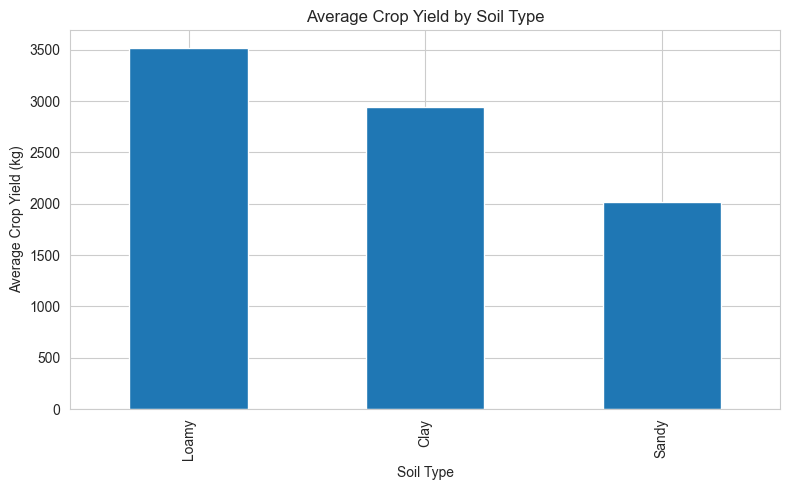

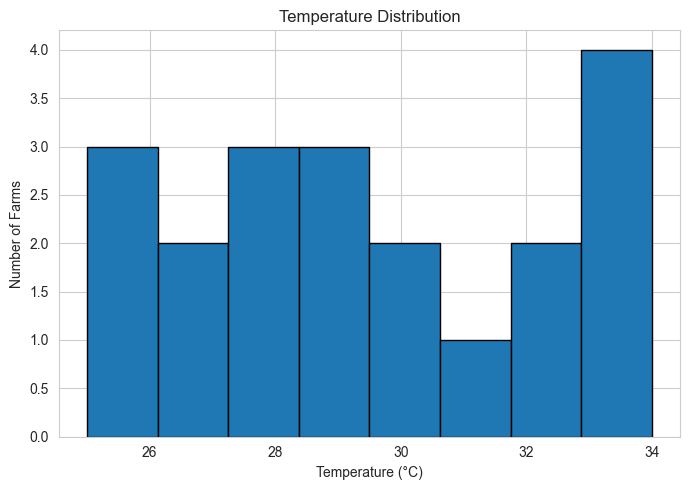

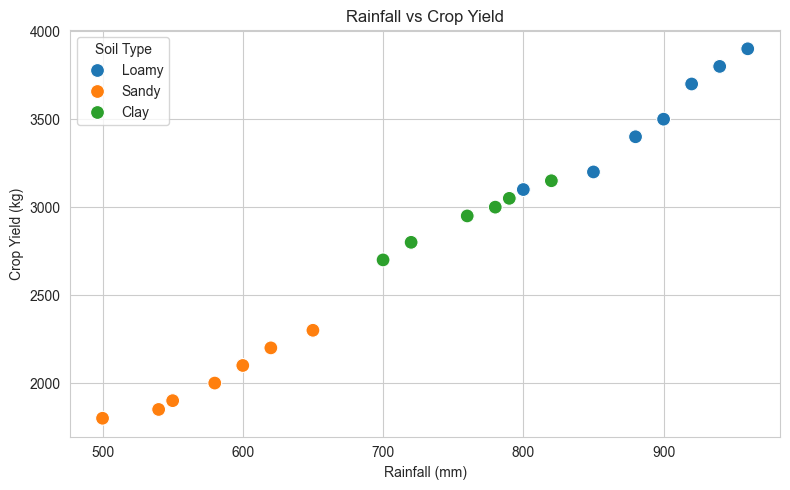

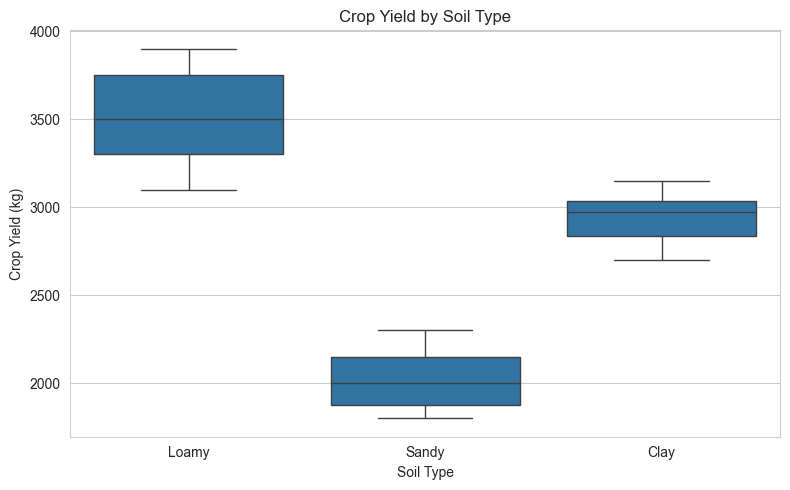

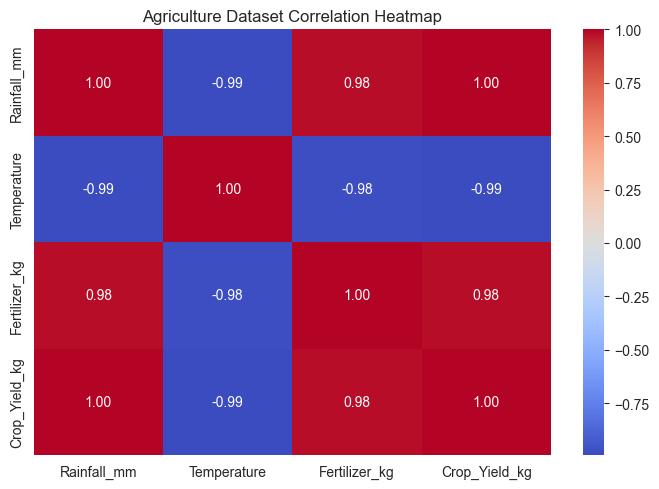

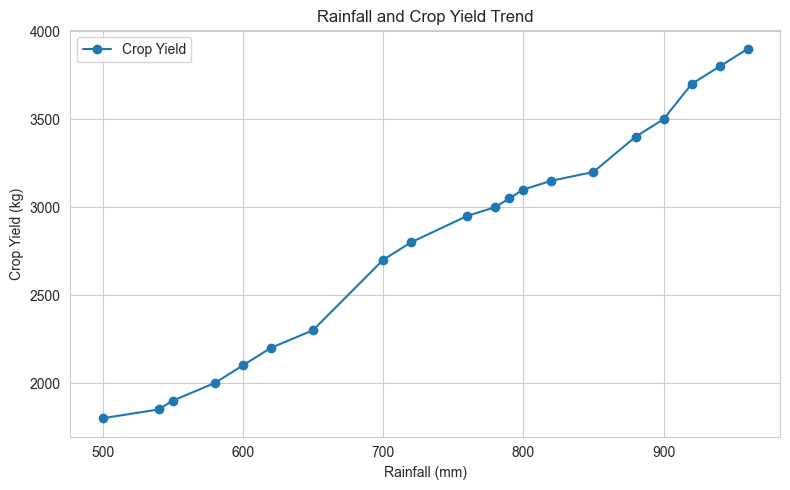

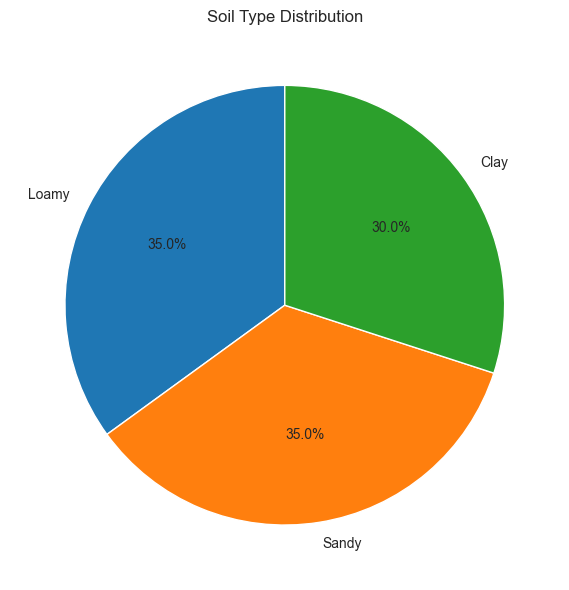

In [52]:
# ============================================================
# AGRICULTURE - DATA VISUALIZATION
# ============================================================

# 1. BAR CHART - Average Yield by Soil Type

average_yield = (
    df_agriculture.groupby("Soil_Type")["Crop_Yield_kg"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

average_yield.plot(kind="bar")

plt.title("Average Crop Yield by Soil Type")
plt.xlabel("Soil Type")
plt.ylabel("Average Crop Yield (kg)")

plt.tight_layout()
plt.savefig("figs/Q5_Agriculture_Bar_Chart.png", dpi=300)
plt.show()


# 2. HISTOGRAM - Temperature Distribution

plt.figure(figsize=(7, 5))

plt.hist(
    df_agriculture["Temperature"],
    bins=8,
    edgecolor="black"
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.savefig("figs/Q5_Agriculture_Histogram.png", dpi=300)
plt.show()


# 3. SCATTER PLOT - Rainfall vs Crop Yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_agriculture,
    x="Rainfall_mm",
    y="Crop_Yield_kg",
    hue="Soil_Type",
    s=100
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Crop Yield (kg)")
plt.legend(title="Soil Type")

plt.tight_layout()
plt.savefig("figs/Q5_Agriculture_Scatter_Plot.png", dpi=300)
plt.show()


# 4. BOX PLOT - Crop Yield by Soil Type

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_agriculture,
    x="Soil_Type",
    y="Crop_Yield_kg"
)

plt.title("Crop Yield by Soil Type")
plt.xlabel("Soil Type")
plt.ylabel("Crop Yield (kg)")

plt.tight_layout()
plt.savefig("figs/Q5_Agriculture_Box_Plot.png", dpi=300)
plt.show()


# 5. HEATMAP

plt.figure(figsize=(7, 5))

correlation = df_agriculture[
    [
        "Rainfall_mm",
        "Temperature",
        "Fertilizer_kg",
        "Crop_Yield_kg"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Agriculture Dataset Correlation Heatmap")

plt.tight_layout()
plt.savefig("figs/Q5_Agriculture_Heatmap.png", dpi=300)
plt.show()


# 6. LINE CHART - Rainfall vs Crop Yield

agriculture_sorted = df_agriculture.sort_values(
    "Rainfall_mm"
)

plt.figure(figsize=(8, 5))

plt.plot(
    agriculture_sorted["Rainfall_mm"],
    agriculture_sorted["Crop_Yield_kg"],
    marker="o",
    label="Crop Yield"
)

plt.title("Rainfall and Crop Yield Trend")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Crop Yield (kg)")
plt.legend()

plt.tight_layout()
plt.savefig("figs/Q5_Agriculture_Line_Chart.png", dpi=300)
plt.show()


# 7. PIE CHART - Soil Type Distribution

plt.figure(figsize=(6, 6))

df_agriculture["Soil_Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Soil Type Distribution")
plt.ylabel("")

plt.tight_layout()
plt.savefig("figs/Q5_Agriculture_Pie_Chart.png", dpi=300)
plt.show()

## Agriculture Crop Yield – Trends, Distributions and Relationships

Rainfall has a strong positive relationship with crop yield, while temperature shows an inverse relationship with yield. Fertilizer usage also has a positive relationship with crop yield. Soil type influences the average yield, with Loamy soil showing strong performance.

## Key Findings and Insights

1. Rainfall is strongly associated with crop yield.
2. Loamy soil produces a high average crop yield.
3. Higher temperature is associated with lower crop yield in this dataset.
4. Fertilizer usage has a positive relationship with crop yield.
5. No missing values or duplicate records were found.

## Decision-Making Impact

The analysis can help agricultural departments plan irrigation and fertilizer usage according to rainfall conditions and soil type.

## Conclusion

The EDA shows that rainfall, temperature, fertilizer usage and soil type are important factors associated with crop yield. These findings can support better irrigation planning, fertilizer management and agricultural decision-making.